## Import Libraries

Imports the required libraries for data processing, machine learning, model evaluation, and visualization.

In [3]:
import numpy as np
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA RTX A6000


## Dataset path and cysteine labels
Cysteine value per cultivar from HPLC. One value per cultivar, shared by all 324 of its spectra.

In [2]:
DATASET_DIR = Path("Dataset")

CULTIVARS = {
    "AAC_Chrome":     {"label": "AAC Chrome",    "cys": 0.317211},
    "AAC_Lacombe":    {"label": "AAC Lacombe",   "cys": 0.338561},
    "AAC_Liscard":    {"label": "AAC Liscard",   "cys": 0.325405},
    "CDC_Amarillo":   {"label": "CDC Amarillo",  "cys": 0.358930},
    "CDC_Athabasca":  {"label": "CDC Athabasca", "cys": 0.341203},
    "CDC_Canary":     {"label": "CDC Canary",    "cys": 0.314476},
    "CDC_Dakota":     {"label": "CDC Dakota",    "cys": 0.332835},
    "CDC_Golden":     {"label": "CDC Golden",    "cys": 0.359066},
    "CDC_Greenwater": {"label": "CDC Greenwater","cys": 0.346381},
    "CDC_Inca":       {"label": "CDC Inca",      "cys": 0.365342},
    "CDC_Jasper":     {"label": "CDC Jasper",    "cys": 0.337341},
    "CDC_Lewochko":   {"label": "CDC Lewochko",  "cys": 0.341267},
    "CDC_Meadow":     {"label": "CDC Meadow",    "cys": 0.312012},
    "CDC_Patrick":    {"label": "CDC Patrick",   "cys": 0.338404},
    "CDC_Saffron":    {"label": "CDC Saffron",   "cys": 0.346789},
    "CDC_Spectrum":   {"label": "CDC Spectrum",  "cys": 0.373175},
    "CDC_Spruce":     {"label": "CDC Spruce",    "cys": 0.345676},
    "CDC_Striker":    {"label": "CDC Striker",   "cys": 0.344968},
    "CDC_Tetris":     {"label": "CDC Tetris",    "cys": 0.342040},
    "Redbat88":       {"label": "Redbat 88",     "cys": 0.316257},
}

## Read one Raman spectrum
Parses a B and W Tek txt file. Returns Raman shifts and dark subtracted intensities.

In [5]:
def read_spectrum(filepath):
    raman_shifts = []
    intensities = []

    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    data_started = False
    for line in lines:
        line = line.strip()
        if line.startswith("Pixel;"):
            data_started = True
            continue
        if not data_started:
            continue
        parts = line.split(';')
        if len(parts) < 8:
            continue
        wl_str = parts[1].strip()
        if not wl_str or wl_str == '   ':
            continue
        try:
            raman_shift = float(parts[3])
            dark_sub    = float(parts[7])
            raman_shifts.append(raman_shift)
            intensities.append(dark_sub)
        except ValueError:
            continue

    return raman_shifts, intensities

## Load all spectra
Walks every cultivar folder and reads all spectrum files.

In [6]:
all_data = {}

for folder_name, meta in CULTIVARS.items():
    folder_path = DATASET_DIR / folder_name
    if not folder_path.exists():
        print(f"Not found: {folder_name}")
        continue
    files = list(folder_path.rglob("*.txt"))
    spectra = []
    for f in files:
        rs, intens = read_spectrum(f)
        if len(rs) > 100:
            spectra.append((rs, intens))
    all_data[folder_name] = spectra
    print(f"{meta['label']}: {len(spectra)} spectra loaded")

AAC Chrome: 324 spectra loaded
AAC Lacombe: 324 spectra loaded
AAC Liscard: 324 spectra loaded
CDC Amarillo: 324 spectra loaded
CDC Athabasca: 324 spectra loaded
CDC Canary: 324 spectra loaded
CDC Dakota: 324 spectra loaded
CDC Golden: 324 spectra loaded
CDC Greenwater: 324 spectra loaded
CDC Inca: 324 spectra loaded
CDC Jasper: 324 spectra loaded
CDC Lewochko: 324 spectra loaded
CDC Meadow: 324 spectra loaded
CDC Patrick: 324 spectra loaded
CDC Saffron: 324 spectra loaded
CDC Spectrum: 324 spectra loaded
CDC Spruce: 324 spectra loaded
CDC Striker: 324 spectra loaded
CDC Tetris: 324 spectra loaded
Redbat 88: 324 spectra loaded


## Preprocessing functions
Savitzky Golay smoothing, SNV, MSC, and derivatives, plus the 8 combinations.

In [7]:
def savitzky_golay_smooth(X, window=11, poly=3):
    return savgol_filter(X, window_length=window, polyorder=poly, axis=1)

def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

def msc(X):
    mean_spectrum = X.mean(axis=0)
    X_msc = np.zeros_like(X)
    for i in range(X.shape[0]):
        coef = np.polyfit(mean_spectrum, X[i], 1)
        X_msc[i] = (X[i] - coef[1]) / coef[0]
    return X_msc

def first_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=1, axis=1)

def second_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=2, axis=1)

preprocessing_combos = {
    "SG + SNV":           lambda X: snv(savitzky_golay_smooth(X)),
    "SG + MSC":           lambda X: msc(savitzky_golay_smooth(X)),
    "SG + 1st Deriv":     lambda X: first_derivative(savitzky_golay_smooth(X)),
    "SG + 2nd Deriv":     lambda X: second_derivative(savitzky_golay_smooth(X)),
    "SG + SNV + 1st Der": lambda X: first_derivative(snv(savitzky_golay_smooth(X))),
    "SG + SNV + 2nd Der": lambda X: second_derivative(snv(savitzky_golay_smooth(X))),
    "SG + MSC + 1st Der": lambda X: first_derivative(msc(savitzky_golay_smooth(X))),
    "SG + MSC + 2nd Der": lambda X: second_derivative(msc(savitzky_golay_smooth(X))),
}

print(f"Preprocessing combinations: {len(preprocessing_combos)}")

Preprocessing combinations: 8


## Build X and y
Result should be X of shape (6480, 1530) and y of shape (6480,).

In [8]:
X = []
y = []

for folder_name, meta in CULTIVARS.items():
    spectra = all_data.get(folder_name, [])
    for rs, intens in spectra:
        X.append(intens)
        y.append(meta['cys'])

X = np.array(X)
y = np.array(y)

cultivar_names = list(CULTIVARS.keys())

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6480, 1530)
y shape: (6480,)


## PCA Dimensionality Check

Tests how much variance is retained at 50, 100, 150 and 200 components.
GPR is slow on very wide data, so the spectra need to be compressed first.

In [9]:
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler

# Test PCA on raw data first
print("Testing PCA dimensionality reduction...")
X_scaled = StandardScaler().fit_transform(X)

# Try different numbers of components
for n_components in [50, 100, 150, 200]:
    pca_test = PCA(n_components=n_components)
    pca_test.fit(X_scaled)
    var_explained = pca_test.explained_variance_ratio_.sum()
    print(f"PCA {n_components} components: {var_explained*100:.1f}% variance explained")

Testing PCA dimensionality reduction...
PCA 50 components: 99.9% variance explained
PCA 100 components: 99.9% variance explained
PCA 150 components: 99.9% variance explained
PCA 200 components: 100.0% variance explained


## GPR Pipeline

Chains scaling, PCA and the GPR model with an RBF plus white noise kernel into one pipeline.
Runs once on a quick 80/20 split to confirm it works end to end.

In [10]:
from sklearn.pipeline import Pipeline

def make_gpr_pipeline(n_components=50):
    # RBF kernel + noise term
    kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=n_components)),
        ('gpr',    GaussianProcessRegressor(
                       kernel=kernel,
                       n_restarts_optimizer=5,
                       normalize_y=True,
                       random_state=42
                   ))
    ])
    return pipeline

# Test pipeline
print("Testing GPR pipeline...")
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline_test = make_gpr_pipeline(n_components=50)
pipeline_test.fit(X_tr, y_tr)
y_pred_test, y_std_test = pipeline_test.predict(X_te, return_std=True)

rmse_test = np.sqrt(mean_squared_error(y_te, y_pred_test))
r2_test   = r2_score(y_te, y_pred_test)
rpd_test  = y_te.std() / rmse_test

print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test R²:   {r2_test:.4f}")
print(f"Test RPD:  {rpd_test:.4f}")
print(f"Mean confidence interval width: {y_std_test.mean():.4f}")

Testing GPR pipeline...
Test RMSE: 0.0059
Test R²:   0.8691
Test RPD:  2.7641
Mean confidence interval width: 0.0065


## Comparing All Preprocessing Combinations

Runs every preprocessing configuration through both the 80/20 split and leave one cultivar out cross validation.
Raw data is added at the end as a baseline.

In [11]:
results_gpr = []

for combo_name, preprocess_fn in preprocessing_combos.items():
    print(f"\n{'='*50}")
    print(f"Testing: {combo_name}")
    print(f"{'='*50}")

    try:
        X_combo = preprocess_fn(X)
    except Exception as e:
        print(f"  Failed: {e}")
        continue

    # 80/20 split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_combo, y, test_size=0.2, random_state=42
    )

    pipeline = make_gpr_pipeline(n_components=50)
    pipeline.fit(X_tr, y_tr)
    y_pred_te, y_std_te = pipeline.predict(X_te, return_std=True)

    rmse_8020 = np.sqrt(mean_squared_error(y_te, y_pred_te))
    r2_8020   = r2_score(y_te, y_pred_te)
    rpd_8020  = y_te.std() / rmse_8020

    print(f"  80/20 → RMSE: {rmse_8020:.4f}  R²: {r2_8020:.4f}  RPD: {rpd_8020:.4f}")
    print(f"  Mean CI width: {y_std_te.mean():.4f}")

    # LOCOCV
    all_true, all_pred, all_std = [], [], []

    for fold_idx, held_out in enumerate(cultivar_names):
        X_tr_l, y_tr_l = [], []
        X_te_l, y_te_l = [], []

        for folder_name, meta in CULTIVARS.items():
            spectra = all_data.get(folder_name, [])
            for rs, intens in spectra:
                arr     = np.array([intens])
                arr_pre = preprocess_fn(arr)[0]
                if folder_name == held_out:
                    X_te_l.append(arr_pre)
                    y_te_l.append(meta['cys'])
                else:
                    X_tr_l.append(arr_pre)
                    y_tr_l.append(meta['cys'])

        pipeline_loco = make_gpr_pipeline(n_components=50)
        pipeline_loco.fit(np.array(X_tr_l), np.array(y_tr_l))
        y_pred_l, y_std_l = pipeline_loco.predict(
            np.array(X_te_l), return_std=True
        )

        fold_rmse = np.sqrt(mean_squared_error(y_te_l, y_pred_l))
        print(f"    Fold {fold_idx+1}/20 {CULTIVARS[held_out]['label']:20s} "
              f"RMSE: {fold_rmse:.4f}  CI: {y_std_l.mean():.4f}")

        all_true.extend(y_te_l)
        all_pred.extend(y_pred_l)
        all_std.extend(y_std_l)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    all_std  = np.array(all_std)

    rmse_loco = np.sqrt(mean_squared_error(all_true, all_pred))
    r2_loco   = r2_score(all_true, all_pred)
    rpd_loco  = all_true.std() / rmse_loco

    print(f"\n  LOCO → RMSE: {rmse_loco:.4f}  R²: {r2_loco:.4f}  RPD: {rpd_loco:.4f}")
    print(f"  Mean LOCO CI width: {all_std.mean():.4f}")

    results_gpr.append({
        "Preprocessing": combo_name,
        "RMSE_8020":     rmse_8020,
        "R2_8020":       r2_8020,
        "RPD_8020":      rpd_8020,
        "RMSE_LOCO":     rmse_loco,
        "R2_LOCO":       r2_loco,
        "RPD_LOCO":      rpd_loco,
        "CI_8020":       y_std_te.mean(),
        "CI_LOCO":       all_std.mean(),
    })

# Raw baseline
print(f"\n{'='*50}")
print("Testing: Raw (no preprocessing)")
print(f"{'='*50}")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline_raw = make_gpr_pipeline(n_components=50)
pipeline_raw.fit(X_tr, y_tr)
y_pred_raw, y_std_raw = pipeline_raw.predict(X_te, return_std=True)

rmse_8020_raw = np.sqrt(mean_squared_error(y_te, y_pred_raw))
r2_8020_raw   = r2_score(y_te, y_pred_raw)
rpd_8020_raw  = y_te.std() / rmse_8020_raw
print(f"  80/20 → RMSE: {rmse_8020_raw:.4f}  R²: {r2_8020_raw:.4f}  RPD: {rpd_8020_raw:.4f}")

all_true_raw, all_pred_raw, all_std_raw = [], [], []
for fold_idx, held_out in enumerate(cultivar_names):
    X_tr_l, y_tr_l = [], []
    X_te_l, y_te_l = [], []
    for folder_name, meta in CULTIVARS.items():
        spectra = all_data.get(folder_name, [])
        for rs, intens in spectra:
            if folder_name == held_out:
                X_te_l.append(intens)
                y_te_l.append(meta['cys'])
            else:
                X_tr_l.append(intens)
                y_tr_l.append(meta['cys'])

    pipeline_raw_loco = make_gpr_pipeline(n_components=50)
    pipeline_raw_loco.fit(np.array(X_tr_l), np.array(y_tr_l))
    y_pred_l, y_std_l = pipeline_raw_loco.predict(
        np.array(X_te_l), return_std=True
    )

    fold_rmse = np.sqrt(mean_squared_error(y_te_l, y_pred_l))
    print(f"    Fold {fold_idx+1}/20 {CULTIVARS[held_out]['label']:20s} "
          f"RMSE: {fold_rmse:.4f}  CI: {y_std_l.mean():.4f}")
    all_true_raw.extend(y_te_l)
    all_pred_raw.extend(y_pred_l)
    all_std_raw.extend(y_std_l)

all_true_raw = np.array(all_true_raw)
all_pred_raw = np.array(all_pred_raw)
all_std_raw  = np.array(all_std_raw)

rmse_loco_raw = np.sqrt(mean_squared_error(all_true_raw, all_pred_raw))
r2_loco_raw   = r2_score(all_true_raw, all_pred_raw)
rpd_loco_raw  = all_true_raw.std() / rmse_loco_raw

print(f"\n  LOCO → RMSE: {rmse_loco_raw:.4f}  R²: {r2_loco_raw:.4f}  RPD: {rpd_loco_raw:.4f}")

results_gpr.append({
    "Preprocessing": "Raw",
    "RMSE_8020":     rmse_8020_raw,
    "R2_8020":       r2_8020_raw,
    "RPD_8020":      rpd_8020_raw,
    "RMSE_LOCO":     rmse_loco_raw,
    "R2_LOCO":       r2_loco_raw,
    "RPD_LOCO":      rpd_loco_raw,
    "CI_8020":       y_std_raw.mean(),
    "CI_LOCO":       all_std_raw.mean(),
})

print("\n ALL GPR COMBINATIONS DONE!")


Testing: SG + SNV
  80/20 → RMSE: 0.0037  R²: 0.9477  RPD: 4.3718
  Mean CI width: 0.0038
    Fold 1/20 AAC Chrome           RMSE: 0.0292  CI: 0.0076
    Fold 2/20 AAC Lacombe          RMSE: 0.0067  CI: 0.0095
    Fold 3/20 AAC Liscard          RMSE: 0.0091  CI: 0.0076
    Fold 4/20 CDC Amarillo         RMSE: 0.0197  CI: 0.0086
    Fold 5/20 CDC Athabasca        RMSE: 0.0090  CI: 0.0073
    Fold 6/20 CDC Canary           RMSE: 0.0284  CI: 0.0146
    Fold 7/20 CDC Dakota           RMSE: 0.0052  CI: 0.0076
    Fold 8/20 CDC Golden           RMSE: 0.0190  CI: 0.0084
    Fold 9/20 CDC Greenwater       RMSE: 0.0060  CI: 0.0098
    Fold 10/20 CDC Inca             RMSE: 0.0236  CI: 0.0102
    Fold 11/20 CDC Jasper           RMSE: 0.0103  CI: 0.0074
    Fold 12/20 CDC Lewochko         RMSE: 0.0151  CI: 0.0080
    Fold 13/20 CDC Meadow           RMSE: 0.0322  CI: 0.0062
    Fold 14/20 CDC Patrick          RMSE: 0.0055  CI: 0.0101
    Fold 15/20 CDC Saffron          RMSE: 0.0298  CI: 0.0065
   

## Results Table and Comparison Plots

Prints the full metrics table and picks the best preprocessing for each evaluation type.
The bar charts show RMSE and R squared side by side for both splits.

              GPR PREPROCESSING COMPARISON RESULTS
Preprocessing              RMSE_8020  R2_8020  RPD_8020  RMSE_LOCO   R2_LOCO  RPD_LOCO   CI_LOCO
-----------------------------------------------------------------------------------------------
SG + SNV                      0.0037   0.9477    4.3718     0.0202   -0.5155    0.8123    0.0086
SG + MSC                      0.0040   0.9408    4.1087     0.0186   -0.2758    0.8853    0.0095
SG + 1st Deriv                0.0164  -0.0002    0.9999     0.0173   -0.1080    0.9500    0.0164
SG + 2nd Deriv                0.0164  -0.0002    0.9999     0.0173   -0.1080    0.9500    0.0164
SG + SNV + 1st Der            0.0164  -0.0002    0.9999     0.0173   -0.1080    0.9500    0.0164
SG + SNV + 2nd Der            0.0164  -0.0002    0.9999     0.0173   -0.1080    0.9500    0.0164
SG + MSC + 1st Der            0.0164  -0.0002    0.9999     0.0173   -0.1080    0.9500    0.0164
SG + MSC + 2nd Der            0.0164  -0.0002    0.9999     0.0173   -0.1080 

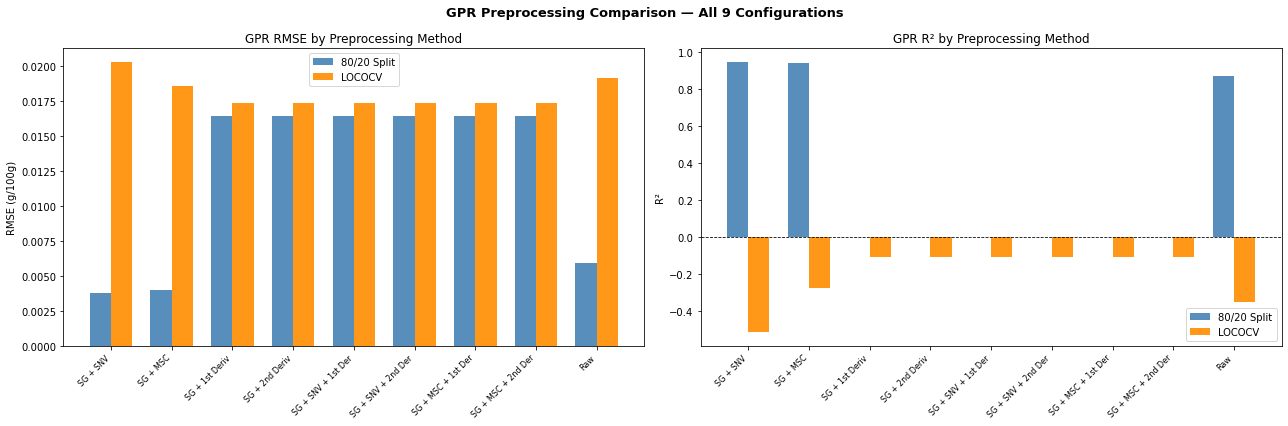

In [12]:
import pandas as pd

df_gpr = pd.DataFrame(results_gpr)

print("="*95)
print("              GPR PREPROCESSING COMPARISON RESULTS")
print("="*95)
print(f"{'Preprocessing':<25} {'RMSE_8020':>10} {'R2_8020':>8} {'RPD_8020':>9} {'RMSE_LOCO':>10} {'R2_LOCO':>9} {'RPD_LOCO':>9} {'CI_LOCO':>9}")
print("-"*95)
for _, row in df_gpr.iterrows():
    print(f"{row['Preprocessing']:<25} "
          f"{row['RMSE_8020']:>10.4f} {row['R2_8020']:>8.4f} {row['RPD_8020']:>9.4f} "
          f"{row['RMSE_LOCO']:>10.4f} {row['R2_LOCO']:>9.4f} {row['RPD_LOCO']:>9.4f} "
          f"{row['CI_LOCO']:>9.4f}")
print("="*95)

best_8020 = df_gpr.loc[df_gpr['RMSE_8020'].idxmin(), 'Preprocessing']
best_loco  = df_gpr.loc[df_gpr['RMSE_LOCO'].idxmin(), 'Preprocessing']
print(f"\nBest 80/20 preprocessing: {best_8020}")
print(f"Best LOCO  preprocessing: {best_loco}")

# ── Preprocessing Comparison Plot ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
labels = df_gpr['Preprocessing'].tolist()
x = np.arange(len(labels))
width = 0.35

ax1 = axes[0]
ax1.bar(x - width/2, df_gpr['RMSE_8020'], width,
        color='steelblue', alpha=0.9, label='80/20 Split')
ax1.bar(x + width/2, df_gpr['RMSE_LOCO'], width,
        color='darkorange', alpha=0.9, label='LOCOCV')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel("RMSE (g/100g)")
ax1.set_title("GPR RMSE by Preprocessing Method")
ax1.legend()

ax2 = axes[1]
ax2.bar(x - width/2, df_gpr['R2_8020'], width,
        color='steelblue', alpha=0.9, label='80/20 Split')
ax2.bar(x + width/2, df_gpr['R2_LOCO'], width,
        color='darkorange', alpha=0.9, label='LOCOCV')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel("R²")
ax2.set_title("GPR R² by Preprocessing Method")
ax2.legend()

plt.suptitle("GPR Preprocessing Comparison — All 9 Configurations",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("GPR_preprocessing_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Best Configurations, Predicted vs True

Reruns the two winning configurations and plots predicted against true cysteine with error bars.
Each cultivar has its own color so the weak ones are easy to spot.


Running: SG + SNV (Best 80/20)
  Fold 1/20 done
  Fold 2/20 done
  Fold 3/20 done
  Fold 4/20 done
  Fold 5/20 done
  Fold 6/20 done
  Fold 7/20 done
  Fold 8/20 done
  Fold 9/20 done
  Fold 10/20 done
  Fold 11/20 done
  Fold 12/20 done
  Fold 13/20 done
  Fold 14/20 done
  Fold 15/20 done
  Fold 16/20 done
  Fold 17/20 done
  Fold 18/20 done
  Fold 19/20 done
  Fold 20/20 done

Running: SG + MSC (Best LOCO)
  Fold 1/20 done
  Fold 2/20 done
  Fold 3/20 done
  Fold 4/20 done
  Fold 5/20 done
  Fold 6/20 done
  Fold 7/20 done
  Fold 8/20 done
  Fold 9/20 done
  Fold 10/20 done
  Fold 11/20 done
  Fold 12/20 done
  Fold 13/20 done
  Fold 14/20 done
  Fold 15/20 done
  Fold 16/20 done
  Fold 17/20 done
  Fold 18/20 done
  Fold 19/20 done
  Fold 20/20 done


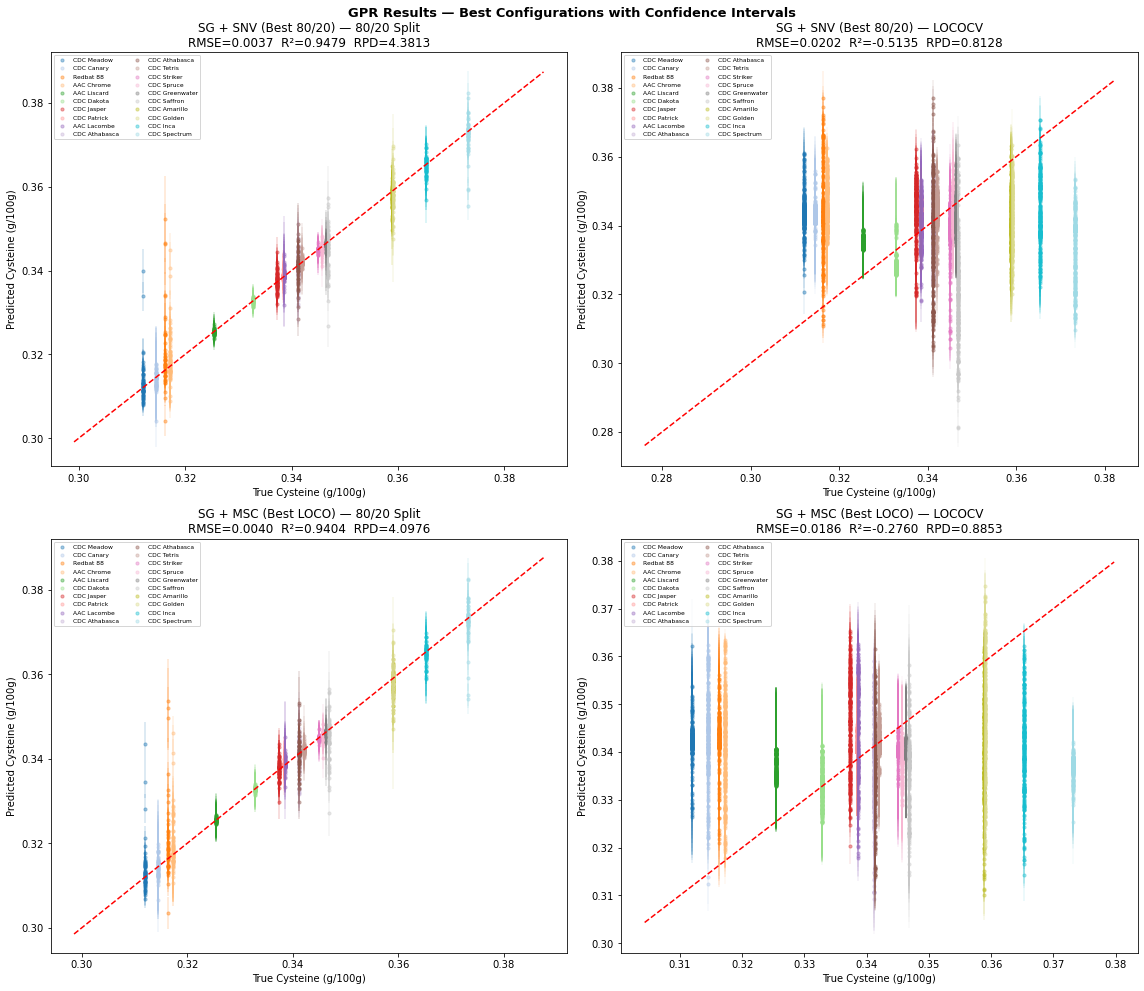

In [13]:
# Best 80/20 = SG + SNV
# Best LOCO  = SG + MSC
# We plot both configurations

configs = {
    "SG + SNV (Best 80/20)": snv(savitzky_golay_smooth(X)),
    "SG + MSC (Best LOCO)":  msc(savitzky_golay_smooth(X)),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
colors = plt.cm.tab20(np.linspace(0, 1, 20))

for row_idx, (config_name, X_config) in enumerate(configs.items()):
    print(f"\nRunning: {config_name}")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_config, y, test_size=0.2, random_state=42
    )

    pipeline = make_gpr_pipeline(n_components=50)
    pipeline.fit(X_tr, y_tr)
    y_pred_te, y_std_te = pipeline.predict(X_te, return_std=True)

    rmse_8020 = np.sqrt(mean_squared_error(y_te, y_pred_te))
    r2_8020   = r2_score(y_te, y_pred_te)
    rpd_8020  = y_te.std() / rmse_8020

    # LOCOCV
    all_true, all_pred, all_std = [], [], []
    for fold_idx, held_out in enumerate(cultivar_names):
        X_tr_l, y_tr_l = [], []
        X_te_l, y_te_l = [], []
        for folder_name, meta in CULTIVARS.items():
            spectra = all_data.get(folder_name, [])
            for rs, intens in spectra:
                arr     = np.array([intens])
                if "SNV" in config_name:
                    arr_pre = snv(savitzky_golay_smooth(arr))[0]
                else:
                    arr_pre = msc(savitzky_golay_smooth(arr))[0]
                if folder_name == held_out:
                    X_te_l.append(arr_pre)
                    y_te_l.append(meta['cys'])
                else:
                    X_tr_l.append(arr_pre)
                    y_tr_l.append(meta['cys'])

        pipeline_loco = make_gpr_pipeline(n_components=50)
        pipeline_loco.fit(np.array(X_tr_l), np.array(y_tr_l))
        y_pred_l, y_std_l = pipeline_loco.predict(
            np.array(X_te_l), return_std=True
        )
        all_true.extend(y_te_l)
        all_pred.extend(y_pred_l)
        all_std.extend(y_std_l)
        print(f"  Fold {fold_idx+1}/20 done")

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    all_std  = np.array(all_std)

    rmse_loco = np.sqrt(mean_squared_error(all_true, all_pred))
    r2_loco   = r2_score(all_true, all_pred)
    rpd_loco  = all_true.std() / rmse_loco

    # 80/20 scatter plot
    ax1 = axes[row_idx][0]
    unique_cys = sorted(set(y_te))
    for i, val in enumerate(unique_cys):
        mask  = y_te == val
        label = [meta['label'] for meta in CULTIVARS.values()
                 if abs(meta['cys'] - val) < 0.0001]
        label = label[0] if label else str(round(val, 4))
        ax1.scatter(y_te[mask], y_pred_te[mask],
                    alpha=0.4, s=10, color=colors[i], label=label)
        # Add confidence intervals
        ax1.errorbar(y_te[mask], y_pred_te[mask],
                     yerr=y_std_te[mask],
                     fmt='none', alpha=0.2, color=colors[i])

    min_val = min(y_te.min(), y_pred_te.min()) - 0.005
    max_val = max(y_te.max(), y_pred_te.max()) + 0.005
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
    ax1.set_xlabel("True Cysteine (g/100g)")
    ax1.set_ylabel("Predicted Cysteine (g/100g)")
    ax1.set_title(f"{config_name} — 80/20 Split\nRMSE={rmse_8020:.4f}  R²={r2_8020:.4f}  RPD={rpd_8020:.4f}")
    ax1.legend(fontsize=6, ncol=2, loc='upper left')

    # LOCO scatter plot
    ax2 = axes[row_idx][1]
    unique_cys_loco = sorted(set(all_true))
    for i, val in enumerate(unique_cys_loco):
        mask  = all_true == val
        label = [meta['label'] for meta in CULTIVARS.values()
                 if abs(meta['cys'] - val) < 0.0001]
        label = label[0] if label else str(round(val, 4))
        ax2.scatter(all_true[mask], all_pred[mask],
                    alpha=0.4, s=10, color=colors[i], label=label)
        ax2.errorbar(all_true[mask], all_pred[mask],
                     yerr=all_std[mask],
                     fmt='none', alpha=0.1, color=colors[i])

    min_val = min(all_true.min(), all_pred.min()) - 0.005
    max_val = max(all_true.max(), all_pred.max()) + 0.005
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
    ax2.set_xlabel("True Cysteine (g/100g)")
    ax2.set_ylabel("Predicted Cysteine (g/100g)")
    ax2.set_title(f"{config_name} — LOCOCV\nRMSE={rmse_loco:.4f}  R²={r2_loco:.4f}  RPD={rpd_loco:.4f}")
    ax2.legend(fontsize=6, ncol=2, loc='upper left')

plt.suptitle("GPR Results — Best Configurations with Confidence Intervals",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("GPR_final_results.png", dpi=150, bbox_inches='tight')
plt.show()